#### MNIST FCN

Reparameterizes the dummy image using a sigmoid: Instead of directly optimizing over a variable representing an image (which may take values outside 0,1), we optimize an unconstrained variable and pass it through a sigmoid so that the dummy image is always in the valid range.

Increases the number of iterations: More updates sometimes help push the dummy image closer to the target.

Adds a slight regularization term: A total variation (TV) regularization term is added to encourage smoothness and promote natural-looking reconstructions.

Explanation:
- Reparameterization using Sigmoid: By optimizing dummy_param and then applying tf.sigmoid(dummy_param), we ensure that our dummy image always has pixel values between 0 and 1. This aligns our optimization with the natural image space.
- Extended Optimization Iterations: Increased iterations (set here to 1000) provide the optimizer more time to reduce the gradient difference. Depending on your setup, you might even experiment with more iterations.
- Total Variation Regularization: The added regularization term tf.image.total_variation(dummy_data) penalizes abrupt changes in the image, thereby promoting smoothness. The regularization weight (0.001) is modest, but you may tweak it based on the reconstruction quality and how much “smoothness” you intend to enforce.

2025-11-05 11:23:43.180010: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Starting the reconstruction attack...
Iteration 0, Total loss: 201.4822
Iteration 100, Total loss: 76.0831
Iteration 200, Total loss: 47.4630
Iteration 300, Total loss: 27.2745
Iteration 400, Total loss: 24.0635
Iteration 500, Total loss: 19.7585
Iteration 600, Total loss: 19.7092
Iteration 700, Total loss: 19.6471
Iteration 800, Total loss: 19.6329
Iteration 900, Total loss: 19.6061


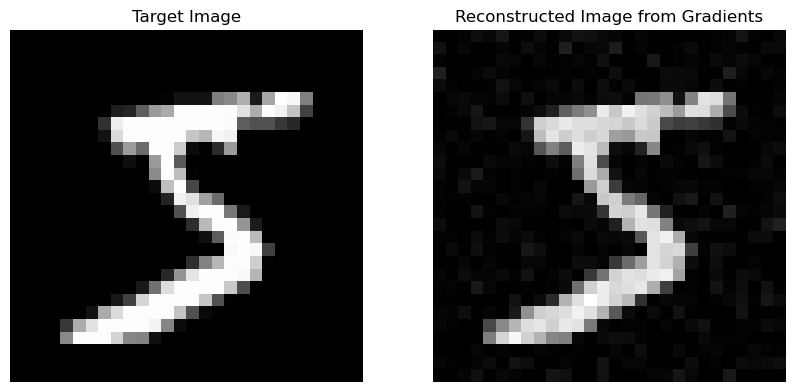

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, losses, optimizers
import numpy as np
import matplotlib.pyplot as plt

# Suppress TensorFlow warnings
tf.get_logger().setLevel("ERROR")

# -----------------------------------
# 1. Define a Simple Neural Network
# -----------------------------------
def create_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10)  # Logits for 10 classes
    ])
    return model

model = create_model()

# -----------------------------------
# 2. Load MNIST and Select a Target Sample
# -----------------------------------
(train_images, train_labels), _ = tf.keras.datasets.mnist.load_data()
train_images = train_images.astype("float32") / 255.0
train_images = np.expand_dims(train_images, -1)  # Shape: (batch, 28, 28, 1)

# Choose one target sample
target_data = tf.convert_to_tensor(train_images[0:1])
target_label = tf.convert_to_tensor(train_labels[0:1])

# -----------------------------------
# 3. Compute the Target Gradients
# -----------------------------------
loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)

with tf.GradientTape() as tape:
    logits = model(target_data)
    target_loss = loss_fn(target_label, logits)
target_grads = tape.gradient(target_loss, model.trainable_variables)

# -----------------------------------
# 4. Simulate the Gradient Leakage Attack with Improvements
# -----------------------------------
# Instead of optimizing dummy data directly, we optimize an unconstrained variable that we
# transform through a sigmoid function to ensure the dummy image is in [0,1].
dummy_param = tf.Variable(tf.random.normal(shape=target_data.shape), trainable=True)

def get_dummy_image():
    # Enforces valid image pixel range
    return tf.sigmoid(dummy_param)

# Use Adam optimizer; you might adjust the learning rate and further fine-tune as needed.
optimizer = optimizers.Adam(learning_rate=0.1)

num_iterations = 1000  # Increased iterations for potentially better convergence

print("Starting the reconstruction attack...")
for i in range(num_iterations):
    with tf.GradientTape() as outer_tape:
        dummy_data = get_dummy_image()
        # Inner tape to compute gradients w.r.t. model parameters for dummy data
        with tf.GradientTape() as inner_tape:
            dummy_logits = model(dummy_data)
            dummy_loss = loss_fn(target_label, dummy_logits)
        dummy_grads = inner_tape.gradient(dummy_loss, model.trainable_variables)
        
        # Compute the L2 difference between dummy gradients and target gradients
        grad_diff = 0.0
        for dg, tg in zip(dummy_grads, target_grads):
            grad_diff += tf.reduce_sum(tf.square(dg - tg))
        
        # Add a regularization term: total variation loss to encourage smoothness.
        reg_loss = tf.reduce_sum(tf.image.total_variation(dummy_data))
        # The regularization weight (0.001) can be tweaked to balance reconstruction vs. smoothness.
        total_loss = grad_diff + 0.001 * reg_loss

    # Compute the gradient of the loss with respect to the dummy parameters (not the image directly).
    grad_dummy = outer_tape.gradient(total_loss, dummy_param)
    optimizer.apply_gradients([(grad_dummy, dummy_param)])
    
    if i % 100 == 0:
        print(f"Iteration {i}, Total loss: {total_loss.numpy():.4f}")

# -----------------------------------
# 5. Visualize the Results
# -----------------------------------
dummy_image = get_dummy_image().numpy().squeeze()   # Reconstructed image from gradients
target_image = target_data.numpy().squeeze()          # Original target image

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Target Image")
plt.imshow(target_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Reconstructed Image from Gradients")
plt.imshow(dummy_image, cmap='gray')
plt.axis('off')

plt.show()



MODEL PERFORMANCE METRICS
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 862us/step
Training Accuracy: 0.9801
Test Accuracy: 0.9713
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Confusion Matrix:


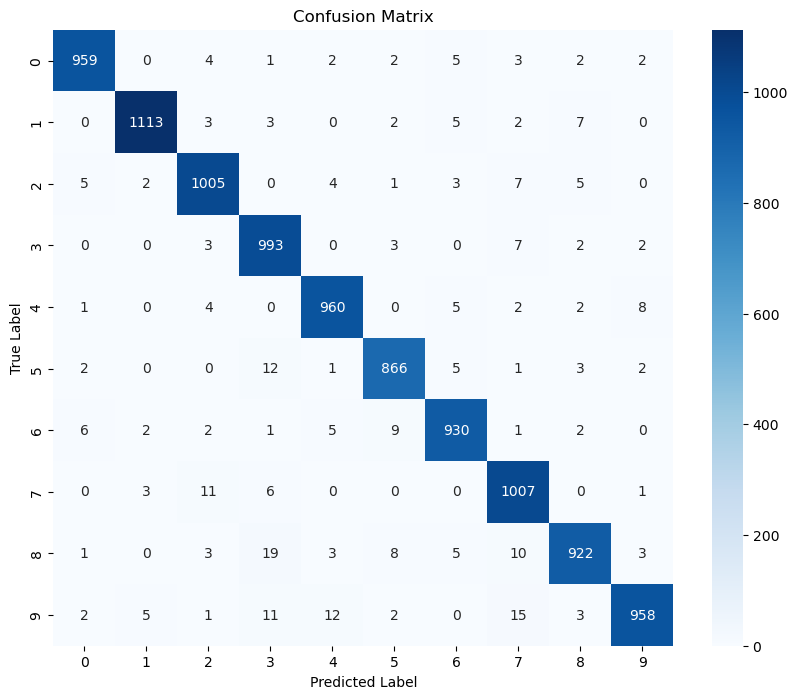


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.99      0.98      0.98      1135
           2       0.97      0.97      0.97      1032
           3       0.95      0.98      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.97      0.97      0.97       892
           6       0.97      0.97      0.97       958
           7       0.95      0.98      0.97      1028
           8       0.97      0.95      0.96       974
           9       0.98      0.95      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000


Overall Metrics:
Precision: 0.9715
Recall: 0.9713
F1-Score: 0.9713


In [3]:
# Add these imports at the top
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# -----------------------------------
# 6. Evaluate Model Performance
# -----------------------------------

# Load test data
(_, _), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
test_images = test_images.astype("float32") / 255.0
test_images = np.expand_dims(test_images, -1)  # Shape: (batch, 28, 28, 1)

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)

# Training accuracy
train_predictions = model.predict(train_images)
train_pred_labels = np.argmax(train_predictions, axis=1)
train_accuracy = np.mean(train_pred_labels == train_labels)
print(f"Training Accuracy: {train_accuracy:.4f}")

# Test accuracy
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predictions for test set
test_predictions = model.predict(test_images)
test_pred_labels = np.argmax(test_predictions, axis=1)

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(test_labels, test_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, test_pred_labels, 
                          target_names=[str(i) for i in range(10)]))

# Overall Precision, Recall, F1-Score
from sklearn.metrics import precision_score, recall_score, f1_score

overall_precision = precision_score(test_labels, test_pred_labels, average='weighted')
overall_recall = recall_score(test_labels, test_pred_labels, average='weighted')
overall_f1 = f1_score(test_labels, test_pred_labels, average='weighted')

print("\nOverall Metrics:")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1-Score: {overall_f1:.4f}")

In [2]:
import tensorflow as tf
import numpy as np

# Re-load dataset if needed
(train_images, train_labels), _ = tf.keras.datasets.mnist.load_data()
train_images = train_images.astype("float32") / 255.0
train_images = np.expand_dims(train_images, -1)

# Select 20 samples from each of the 10 digit classes
samples_per_class = 20
selected_data = []
selected_labels = []

for digit in range(10):
    idx = np.where(train_labels == digit)[0][:samples_per_class]
    selected_data.append(train_images[idx])
    selected_labels.append(train_labels[idx])

selected_data = np.concatenate(selected_data, axis=0)
selected_labels = np.concatenate(selected_labels, axis=0)

selected_data = tf.convert_to_tensor(selected_data)
selected_labels = tf.convert_to_tensor(selected_labels)

print("Selected dataset shape:", selected_data.shape)


Selected dataset shape: (200, 28, 28, 1)


In [3]:
import tensorflow as tf

def abs_l2(x, y):
    return tf.norm(x - y).numpy()

def rel_l2(x, y):
    return (tf.norm(x - y) / tf.norm(x)).numpy()

def cos_sim(x, y):
    x = tf.reshape(x, [-1])
    y = tf.reshape(y, [-1])
    return (tf.reduce_sum(x*y) / (tf.norm(x)*tf.norm(y))).numpy()


In [4]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

def reconstruct_from_gradients(model, target_image, target_label, target_grads,
                               num_iter=300, lr=0.1, reg=0.001):
    dummy_param = tf.Variable(tf.random.normal(shape=target_image.shape))
    optimizer = tf.keras.optimizers.Adam(lr)

    for _ in range(num_iter):
        with tf.GradientTape() as outer_tape:
            dummy_data = tf.sigmoid(dummy_param)
            with tf.GradientTape() as inner_tape:
                logits = model(dummy_data)
                loss = loss_fn(target_label, logits)
            dummy_grads = inner_tape.gradient(loss, model.trainable_variables)

            grad_diff = tf.add_n([tf.reduce_sum(tf.square(dg - tg))
                                  for dg, tg in zip(dummy_grads, target_grads)])
            reg_loss = tf.reduce_sum(tf.image.total_variation(dummy_data))
            total_loss = grad_diff + reg * reg_loss

        grad_param = outer_tape.gradient(total_loss, dummy_param)
        optimizer.apply_gradients([(grad_param, dummy_param)])

    return tf.sigmoid(dummy_param)


In [5]:
import copy

def defense_none(grads):
    return grads

def defense_dp(grads, sigma=0.01):
    return [g + sigma*tf.random.normal(g.shape) for g in grads]

def defense_clip_noise(grads, clip=0.1, noise=0.005):
    clipped = [tf.clip_by_value(g, -clip, clip) for g in grads]
    return [g + noise*tf.random.normal(g.shape) for g in clipped]

def defense_secure_aggregation(grads_list):
    # grads_list = list of gradients from multiple samples
    return [tf.reduce_mean(tf.stack(gs), axis=0) for gs in zip(*grads_list)]

def defense_quantize(grads, levels=16):
    return [tf.round(g * levels) / levels for g in grads]

def defense_adv_training(grads, eps=0.01):
    return [g + eps*tf.sign(g) for g in grads]


In [6]:
defenses = {
    "None": defense_none,
    "Differential Privacy": defense_dp,
    "Gradient Clipping + Perturbation": defense_clip_noise,
    "Model Quantization": defense_quantize,
    "Adversarial Training": defense_adv_training
}

results = {name: [] for name in defenses.keys()}

for i in range(len(selected_data)):
    x = selected_data[i:i+1]
    y = selected_labels[i:i+1]

    # True gradients
    with tf.GradientTape() as tape:
        logits = model(x)
        loss = loss_fn(y, logits)
    true_grads = tape.gradient(loss, model.trainable_variables)

    # Compute reconstruction under each defense
    for dname, dfn in defenses.items():
        defended_grads = dfn(true_grads)
        recon = reconstruct_from_gradients(model, x, y, defended_grads)
        results[dname].append([
            abs_l2(x, recon),
            rel_l2(x, recon),
            cos_sim(x, recon)
        ])

print("✅ Reconstruction Complete")


✅ Reconstruction Complete


In [7]:
import numpy as np
import pandas as pd

avg_results = {d: np.mean(results[d], axis=0) for d in results}
df = pd.DataFrame(avg_results, index=["Abs L2", "Rel L2", "Cosine Similarity"]).T
print(df)

                                    Abs L2    Rel L2  Cosine Similarity
None                              3.035002  0.392574           0.920974
Differential Privacy              2.919134  0.375532           0.926969
Gradient Clipping + Perturbation  8.773994  1.042522           0.704453
Model Quantization                3.158086  0.406094           0.918462
Adversarial Training              2.330793  0.302732           0.946779


In [10]:
# --- Secure Aggregation for MNIST (single cell) ---
import numpy as np
import tensorflow as tf

# Parameters
k = 10  # group size for secure aggregation (1 target + k-1 random others)
num_samples = selected_data.shape[0]  # should be 200 (20 per class)
secure_results_mnist = []  # will collect [abs_l2, rel_l2, cos_sim] per target

# Ensure selected_data/labels are tensors
if not isinstance(selected_data, tf.Tensor):
    selected_data_tf = tf.convert_to_tensor(selected_data)
else:
    selected_data_tf = selected_data

if not isinstance(selected_labels, tf.Tensor):
    selected_labels_tf = tf.convert_to_tensor(selected_labels)
else:
    selected_labels_tf = selected_labels

# Helper: compute gradients for one sample (returns list of tensors)
def compute_tf_grads(x_sample, y_sample):
    with tf.GradientTape() as tape:
        logits = model(x_sample)
        loss = loss_fn(y_sample, logits)
    grads = tape.gradient(loss, model.trainable_variables)
    return grads

# Run secure-aggregation reconstructions
for i in range(num_samples):
    # target sample (shape [1,28,28,1])
    x_target = tf.expand_dims(selected_data_tf[i], axis=0)
    y_target = tf.expand_dims(selected_labels_tf[i], axis=0)

    # build indices for group: target + k-1 random distinct others
    idx_pool = list(range(num_samples))
    idx_pool.remove(i)
    other_idx = np.random.choice(idx_pool, size=(k-1,), replace=False).astype(np.int32)
    # create TF indices and gather
    group_indices = tf.concat([tf.constant([i], dtype=tf.int32), tf.constant(other_idx, dtype=tf.int32)], axis=0)
    group_x = tf.gather(selected_data_tf, group_indices)   # shape (k,28,28,1)
    group_y = tf.gather(selected_labels_tf, group_indices) # shape (k,)

    # compute gradients for each member in the group (list of list-of-tensors)
    group_grads_list = []
    for j in range(k):
        x_j = tf.expand_dims(group_x[j], axis=0)
        y_j = tf.expand_dims(group_y[j], axis=0)
        g_j = compute_tf_grads(x_j, y_j)
        group_grads_list.append(g_j)

    # secure aggregate (use your already-defined function defense_secure_aggregation)
    # it expects a list where each element is a list of per-parameter tensors (group_grads_list)
    agg_grads = defense_secure_aggregation(group_grads_list)

    # reconstruct from aggregated gradients using your reconstruct_from_gradients function
    recon_img = reconstruct_from_gradients(model, x_target, y_target, agg_grads)

    # compute metrics
    a = abs_l2(x_target, recon_img)
    r = rel_l2(x_target, recon_img)
    c = cos_sim(x_target, recon_img)
    secure_results_mnist.append([a, r, c])

# Aggregate and print results
secure_results_mnist = np.array(secure_results_mnist)
secure_avg = secure_results_mnist.mean(axis=0)
secure_std = secure_results_mnist.std(axis=0)

print("Secure Aggregation (MNIST)  aggregated over selected samples:")
print(f"Abs L2: {secure_avg[0]:.6f} ± {secure_std[0]:.6f}")
print(f"Rel L2: {secure_avg[1]:.6f} ± {secure_std[1]:.6f}")
print(f"Cosine Similarity: {secure_avg[2]:.6f} ± {secure_std[2]:.6f}")

# Optional: make a small DataFrame (one row) and display
import pandas as pd
df_secure = pd.DataFrame([{
    "defense": "Secure Aggregation",
    "Abs L2": secure_avg[0],
    "Rel L2": secure_avg[1],
    "Cosine Similarity": secure_avg[2]
}])
print(df_secure)


Secure Aggregation (MNIST)  aggregated over selected samples:
Abs L2: 14.477057 ± 0.636546
Rel L2: 1.636838 ± 0.326475
Cosine Similarity: 0.340624 ± 0.060463
              defense     Abs L2    Rel L2  Cosine Similarity
0  Secure Aggregation  14.477057  1.636838           0.340624


##### Re-run for three samples.

Starting gradient-based attacks on 3 target images...

Attacking target image index: 0
Iteration 0, Total loss: 156.2361
Iteration 100, Total loss: 51.8470
Iteration 200, Total loss: 6.1748
Iteration 300, Total loss: 3.1190
Iteration 400, Total loss: 2.9151
Iteration 500, Total loss: 3.8119
Iteration 600, Total loss: 2.7772
Iteration 700, Total loss: 2.7475
Iteration 800, Total loss: 3.7151
Iteration 900, Total loss: 2.7136

Attacking target image index: 1
Iteration 0, Total loss: 241.9649
Iteration 100, Total loss: 39.2992
Iteration 200, Total loss: 12.4188
Iteration 300, Total loss: 14.4431
Iteration 400, Total loss: 14.6105
Iteration 500, Total loss: 14.9938
Iteration 600, Total loss: 12.9447
Iteration 700, Total loss: 13.3763
Iteration 800, Total loss: 13.3564
Iteration 900, Total loss: 14.4846

Attacking target image index: 2
Iteration 0, Total loss: 230.1955
Iteration 100, Total loss: 57.8788
Iteration 200, Total loss: 51.3802
Iteration 300, Total loss: 43.8084
Iteration 400, Tot

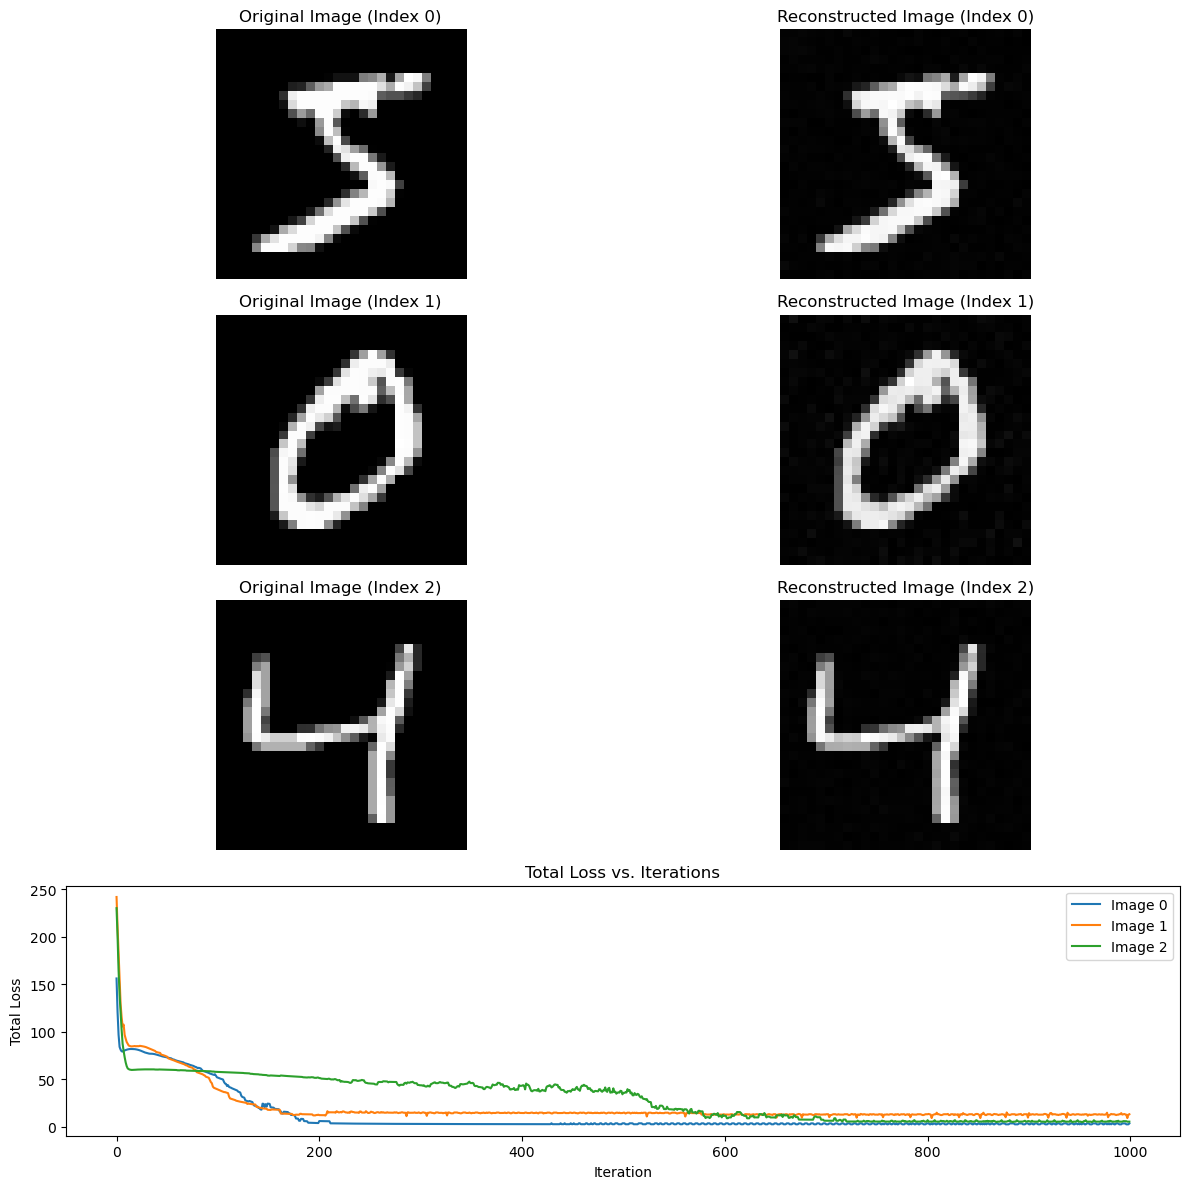

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, losses
from tensorflow.keras.optimizers import legacy as legacy_optimizers
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Suppress TensorFlow warnings
tf.get_logger().setLevel("ERROR")

# -----------------------------------
# 1. Define a Simple Neural Network (FCNN)
# -----------------------------------
def create_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),  # Flatten the input image
        layers.Dense(128, activation='relu'),     # Hidden layer with 128 neurons
        layers.Dense(10)                          # Output logits for 10 classes
    ])
    return model

model = create_model()

# -----------------------------------
# 2. Load MNIST dataset
# -----------------------------------
(train_images, train_labels), _ = tf.keras.datasets.mnist.load_data()
train_images = train_images.astype("float32") / 255.0
train_images = np.expand_dims(train_images, -1)  # Shape: (batch, 28, 28, 1)

# -----------------------------------
# Hyperparameters for the attack and training
# -----------------------------------
loss_fn = losses.SparseCategoricalCrossentropy(from_logits=True)
num_iterations = 1000
reg_weight = 0.001  # Regularization weight for total variation loss

# Lists to store results for each target image
original_images = []
reconstructed_images = []
loss_curves = []

# Define target indices (you can choose any three images from the training set)
target_indices = [0, 1, 2]

print("Starting gradient-based attacks on 3 target images...")

for idx in target_indices:
    print(f"\nAttacking target image index: {idx}")
    
    # Get target image and corresponding label (batch size of 1)
    target_data = tf.convert_to_tensor(train_images[idx:idx+1])
    target_label = tf.convert_to_tensor([train_labels[idx]])
    
    # -----------------------------------
    # 3. Compute the Target Gradients
    # -----------------------------------
    with tf.GradientTape() as tape:
        logits = model(target_data)
        target_loss = loss_fn(target_label, logits)
    target_grads = tape.gradient(target_loss, model.trainable_variables)
    
    # -----------------------------------
    # 4. Simulate the Gradient Leakage Attack
    # -----------------------------------
    # Initialize a dummy parameter for this target image
    dummy_param = tf.Variable(tf.random.normal(shape=target_data.shape), trainable=True)
    # Using the legacy optimizer to ensure the new dummy parameter is recognized
    optimizer = legacy_optimizers.Adam(learning_rate=0.1)
    
    # Define a function to obtain the dummy image (enforcing valid [0,1] range)
    def get_dummy_image():
        return tf.sigmoid(dummy_param)
    
    # Record the loss at every iteration
    loss_history = []
    
    for i in range(num_iterations):
        with tf.GradientTape() as outer_tape:
            dummy_data = get_dummy_image()
            # Inner tape to compute gradients w.r.t. model parameters for dummy data
            with tf.GradientTape() as inner_tape:
                dummy_logits = model(dummy_data)
                dummy_loss = loss_fn(target_label, dummy_logits)
            dummy_grads = inner_tape.gradient(dummy_loss, model.trainable_variables)
            
            # Compute the L2 difference between dummy gradients and target gradients
            grad_diff = 0.0
            for dg, tg in zip(dummy_grads, target_grads):
                grad_diff += tf.reduce_sum(tf.square(dg - tg))
            
            # Add total variation loss for smoothness regularization
            reg_loss = tf.reduce_sum(tf.image.total_variation(dummy_data))
            total_loss = grad_diff + reg_weight * reg_loss
        
        # Compute gradient of total loss with respect to dummy_param and update
        grad_dummy = outer_tape.gradient(total_loss, dummy_param)
        optimizer.apply_gradients([(grad_dummy, dummy_param)])
        
        loss_history.append(total_loss.numpy())
        if i % 100 == 0:
            print(f"Iteration {i}, Total loss: {total_loss.numpy():.4f}")
    
    # Store the results for this target image
    reconstructed_images.append(get_dummy_image().numpy().squeeze())
    original_images.append(target_data.numpy().squeeze())
    loss_curves.append(loss_history)

# -----------------------------------
# 5. Visualize the Results and Save as PDF
# -----------------------------------
# Create a grid with 4 rows and 2 columns: 
# - The first 3 rows display original and reconstructed image pairs for each target.
# - The 4th row spans both columns to show the loss curves.
fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(nrows=4, ncols=2, height_ratios=[1,1,1,1])

for i in range(len(target_indices)):
    ax_orig = fig.add_subplot(gs[i, 0])
    ax_orig.imshow(original_images[i], cmap='gray')
    ax_orig.set_title(f"Original Image (Index {target_indices[i]})")
    ax_orig.axis('off')
    
    ax_recon = fig.add_subplot(gs[i, 1])
    ax_recon.imshow(reconstructed_images[i], cmap='gray')
    ax_recon.set_title(f"Reconstructed Image (Index {target_indices[i]})")
    ax_recon.axis('off')

ax_loss = fig.add_subplot(gs[3, :])  # This subplot spans both columns
for i in range(len(target_indices)):
    ax_loss.plot(loss_curves[i], label=f"Image {target_indices[i]}")
ax_loss.set_title("Total Loss vs. Iterations")
ax_loss.set_xlabel("Iteration")
ax_loss.set_ylabel("Total Loss")
ax_loss.legend()

plt.tight_layout()
plt.savefig("attack_results.pdf")  # Save the entire plot in one PDF file
plt.show()


##### Plotting 

C:\Users\rrk307\AppData\Local\Temp\ipykernel_3940\2610230771.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


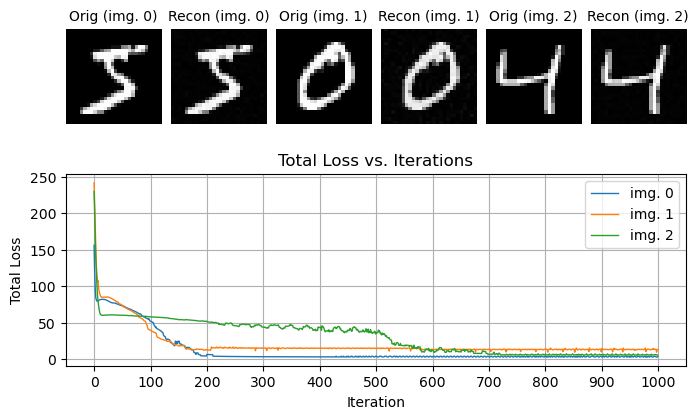

In [58]:
# -----------------------------------
# 5. Visualize the Results and Save as PDF
# -----------------------------------
# Arrange all the image pairs in one row (original and reconstructed images for each target 
# occupy two subplots each, resulting in 6 subplots in the top row) and the loss curves in the 
# bottom row spanning all 6 columns.
fig = plt.figure(figsize=(8, 5))
gs = gridspec.GridSpec(nrows=2, ncols=6, height_ratios=[1, 1], hspace=0.01, wspace=0.1)

# Top row: display original and reconstructed images for each target (6 subplots)
for i in range(len(target_indices)):
    ax_orig = fig.add_subplot(gs[0, 2*i])
    ax_orig.imshow(np.squeeze(original_images[i]), cmap='gray')
    ax_orig.set_title(f"Orig (img. {target_indices[i]})", fontsize=10)
    ax_orig.axis('off')
    
    ax_recon = fig.add_subplot(gs[0, 2*i+1])
    ax_recon.imshow(np.squeeze(reconstructed_images[i]), cmap='gray')
    ax_recon.set_title(f"Recon (img. {target_indices[i]})", fontsize=10)
    ax_recon.axis('off')

# Bottom row: loss curve spanning all 6 columns, matching the image row's size
ax_loss = fig.add_subplot(gs[1, :])
for i in range(len(target_indices)):
    ax_loss.plot(loss_curves[i], label=f"img. {target_indices[i]}", linewidth=1)
ax_loss.set_title("Total Loss vs. Iterations", fontsize=12)
ax_loss.set_xlabel("Iteration", fontsize=10)
ax_loss.set_ylabel("Total Loss", fontsize=10)
ax_loss.legend(fontsize=10, loc='upper right')
ax_loss.grid()
ax_loss.set_xticks([0,100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])

plt.tight_layout()
plt.savefig("attack_results_mnist.pdf", format="pdf")
plt.show()
